# Cluster Centroids

### 1) Import Required Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### 2) Load the dataset

In [2]:
df = pd.read_csv("Dataset/dataset_cluster_centroids.csv")

In [3]:
df['insider'].value_counts()

insider
0    1307
1    1307
Name: count, dtype: int64

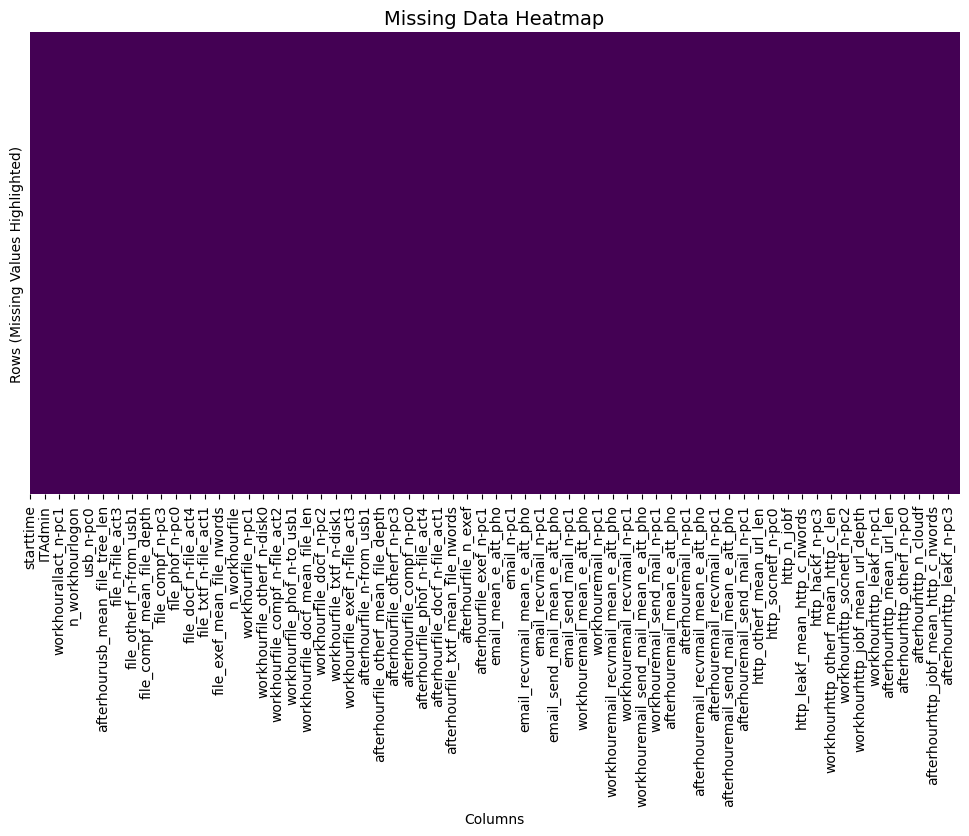

In [28]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title("Missing Data Heatmap", fontsize=14)
plt.xlabel("Columns")
plt.ylabel("Rows (Missing Values Highlighted)")
plt.savefig("missing_values_cc.png", dpi=300, bbox_inches='tight')
plt.show()

In [4]:
X = df.drop(columns=['insider'])
y = df['insider']

In [17]:
features = list(X.columns)

### 3) Train-Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=6
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2091, 829)
Test shape: (523, 829)


### 4) Standardization

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 5) PCA

In [7]:
from sklearn.decomposition import PCA

# Logistic Regression
pca_lr = PCA(n_components=2, whiten=True)
X_train_pca_lr = pca_lr.fit_transform(X_train)
X_test_pca_lr = pca_lr.transform(X_test)

# Decision Tree
pca_dt = PCA(n_components=4)
X_train_pca_dt = pca_dt.fit_transform(X_train)
X_test_pca_dt = pca_dt.transform(X_test)

# Random Forest
pca_rf = PCA(n_components=8)
X_train_pca_rf = pca_rf.fit_transform(X_train)
X_test_pca_rf = pca_rf.transform(X_test)

# AdaBoost
pca_ab = PCA(n_components=8)
X_train_pca_ab = pca_ab.fit_transform(X_train)
X_test_pca_ab = pca_ab.transform(X_test)

# Naive Bayes
pca_nb = PCA(n_components=8)
X_train_pca_nb = pca_nb.fit_transform(X_train)
X_test_pca_nb = pca_nb.transform(X_test)

### 6) ML Models

In [8]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=100)
lr.fit(X_train_pca_lr, y_train)

probs = lr.predict_proba(X_test_pca_lr)[:, 1]
preds = (probs > 0.30).astype(int) 

print("Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, preds):.2%}")
print(classification_report(y_test, preds, target_names=['NO', 'YES']))

Logistic Regression
Accuracy: 78.01%
              precision    recall  f1-score   support

          NO       0.88      0.66      0.75       267
         YES       0.72      0.90      0.80       256

    accuracy                           0.78       523
   macro avg       0.80      0.78      0.78       523
weighted avg       0.80      0.78      0.78       523



In [11]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion='gini',      
    max_depth=15,          
    min_samples_leaf=1,    
    random_state=6      
)

dt.fit(X_train_pca_dt, y_train)
y_pred_dt = dt.predict(X_test_pca_dt)

print("Decision Tree")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.0%}")
print(classification_report(y_test, y_pred_dt, target_names=['NO', 'YES']))

Decision Tree
Accuracy: 98%
              precision    recall  f1-score   support

          NO       0.98      0.98      0.98       267
         YES       0.98      0.98      0.98       256

    accuracy                           0.98       523
   macro avg       0.98      0.98      0.98       523
weighted avg       0.98      0.98      0.98       523



In [12]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=15, 
    max_depth=5, 
    random_state=42
)

rf.fit(X_train_pca_rf, y_train)
probs = rf.predict_proba(X_test_pca_rf)[:, 1]

t = 0.615
preds = (probs > t).astype(int)

print("Random Forest")
print(f"Accuracy: {accuracy_score(y_test, preds):.0%}")
print(classification_report(y_test, preds, target_names=['NO', 'YES']))

Random Forest
Accuracy: 98%
              precision    recall  f1-score   support

          NO       0.96      1.00      0.98       267
         YES       1.00      0.95      0.97       256

    accuracy                           0.98       523
   macro avg       0.98      0.97      0.98       523
weighted avg       0.98      0.98      0.98       523



In [13]:
# AdaBoost
from sklearn.ensemble import AdaBoostClassifier

base_estimator = DecisionTreeClassifier(max_depth=1)

ada = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=100,      
    learning_rate=0.5,    
    random_state=6
)

ada.fit(X_train_pca_ab, y_train)

probs = ada.predict_proba(X_test_pca_ab)[:, 1]

y_pred_ada = (probs > 0.45).astype(int)


print("AdaBoost")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada):.0%}")
print(classification_report(y_test, y_pred_ada))

AdaBoost
Accuracy: 98%
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       267
           1       0.98      0.98      0.98       256

    accuracy                           0.98       523
   macro avg       0.98      0.98      0.98       523
weighted avg       0.98      0.98      0.98       523



In [14]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_pca_nb, y_train)
y_pred_nb = nb.predict(X_test_pca_nb)

print("Naive Bayes")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.2%}")
print(classification_report(y_test, y_pred_nb))

Naive Bayes
Accuracy: 81.64%
              precision    recall  f1-score   support

           0       0.75      0.96      0.84       267
           1       0.93      0.67      0.78       256

    accuracy                           0.82       523
   macro avg       0.84      0.81      0.81       523
weighted avg       0.84      0.82      0.81       523



### 7) Ensemble Learning

In [15]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('dt', dt),
    ('rf', rf),
    ('ada', ada)
]

voting = VotingClassifier(
    estimators=estimators,
    voting='soft'
)

voting.fit(X_train_pca_rf, y_train)

y_pred_vote = voting.predict(X_test_pca_rf)

print("Voting Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_vote):.2%}")
print(classification_report(y_test, y_pred_vote, target_names=['NO', 'YES']))

Voting Classifier
Accuracy: 98.85%
              precision    recall  f1-score   support

          NO       0.99      0.99      0.99       267
         YES       0.99      0.98      0.99       256

    accuracy                           0.99       523
   macro avg       0.99      0.99      0.99       523
weighted avg       0.99      0.99      0.99       523



In [16]:
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=200)
)

stack.fit(X_train_pca_rf, y_train)

y_pred_stack = stack.predict(X_test_pca_rf)

print("Stacking Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_stack):.2%}")
print(classification_report(y_test, y_pred_stack, target_names=['NO', 'YES']))

Stacking Classifier
Accuracy: 98.66%
              precision    recall  f1-score   support

          NO       0.98      0.99      0.99       267
         YES       0.99      0.98      0.99       256

    accuracy                           0.99       523
   macro avg       0.99      0.99      0.99       523
weighted avg       0.99      0.99      0.99       523



### 8) Visualization

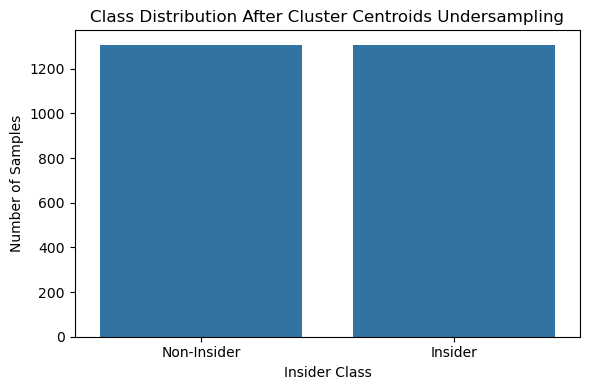

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(x='insider', data=df)

plt.title("Class Distribution After Cluster Centroids Undersampling")
plt.xlabel("Insider Class")
plt.ylabel("Number of Samples")

plt.xticks([0,1], ['Non-Insider','Insider'])

plt.tight_layout()
plt.savefig("class_dist_cc.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
import joblib

joblib.dump({
    "scaler": scaler,
    "pca": pca_rf,
    "model": voting,
    "features": features
}, "cc_voting_model.pkl")

['cc_voting_model.pkl']

In [19]:
import joblib

joblib.dump({
    "scaler": scaler,
    "pca": pca_rf,
    "model": stack,
    "features": features
}, "cc_stacking_model.pkl")

['cc_stacking_model.pkl']